<a href="https://colab.research.google.com/github/sara-iqbal/FX-Risk-Management-Derivative-Structuring-Tool/blob/main/FX_Risk_Management_%26_Derivative_Structuring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


This project demonstrates a quantitative approach to managing foreign exchange risk for corporate clients. It automates the process of fetching market data, calculating volatility, and pricing structured hedging solutions (specifically Zero-Cost Collars) to provide a data-driven alternative to simple Forward contracts.

**Step 1: Data Acquisition**

I utilized the yfinance API to pull real-time and historical market data for GBP/USD (The Cable). This provides the foundation for any FX analysis, ensuring that our pricing is based on the current "Spot" market.

In [1]:
!pip install yfinance
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

**Step 2: Statistical Analysis (Volatility)**
Calculated the Annualized Historical Volatility using a 252-day trading window.

The Logic: Volatility is the primary driver of option premiums. By quantifying this, I can determine if the market is currently overpricing or underpricing risk relative to historical norms.

In [4]:
# Step 2: Fetch and Clean Data
ticker = "GBPUSD=X"
data = yf.download(ticker, period="1y", interval="1d", auto_adjust=True)

# Calculate daily returns
data['Returns'] = np.log(data['Close'] / data['Close'].shift(1))

# Calculate annualized volatility - using float() to be safe
hist_vol = float(data['Returns'].std()) * np.sqrt(252)

# Get the most recent spot price
current_spot = float(data['Close'].iloc[-1])

print(f"Current Spot Rate: {current_spot:.4f}")
print(f"Annualized Historical Volatility: {hist_vol:.2%}")

[*********************100%***********************]  1 of 1 completed

Current Spot Rate: 1.3403
Annualized Historical Volatility: 7.12%



/tmp/ipykernel_519/912648296.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_spot = float(data['Close'].iloc[-1])


**Step 3: Quantitative Pricing Engine**

I implemented the Black-Scholes-Merton (BSM) Model specifically adjusted for currency markets.The Inputs: Spot rate, Strike price, Time to maturity, and the Interest Rate Differential ($r_{domestic} - r_{foreign}$).Technical Detail: This proves the ability to model the "Fair Value" of FX derivatives beyond simple spot trades.

In [6]:
# Force spot to be a simple float
spot = float(data['Close'].iloc[-1])

# Now all calculations derived from spot will be floats
strike = spot * 1.02
time = 0.25
r_gbp = 0.0525
r_usd = 0.0550

# Calculate premium
call_premium = black_scholes_fx(spot, strike, time, r_gbp, r_usd, hist_vol)

# This will now work without the TypeError
print(f"Spot Rate: {spot:.4f}")
print(f"Strike Price: {strike:.4f}")
print(f"Premium for 3-month Call: {float(call_premium):.5f} USD per GBP")

Spot Rate: 1.3403
Strike Price: 1.3671
Premium for 3-month Call: 0.00836 USD per GBP


/tmp/ipykernel_519/1072363512.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  spot = float(data['Close'].iloc[-1])


**Step 5: Scenario Analysis & Visualization**

I created a comprehensive visual dashboard using matplotlib.

Comparison: The graph compares an Unhedged position, a Fixed Forward, and the Structured Collar.

Goal: This serves as a "CFO-ready" visual to communicate complex P&L outcomes under different market conditions.

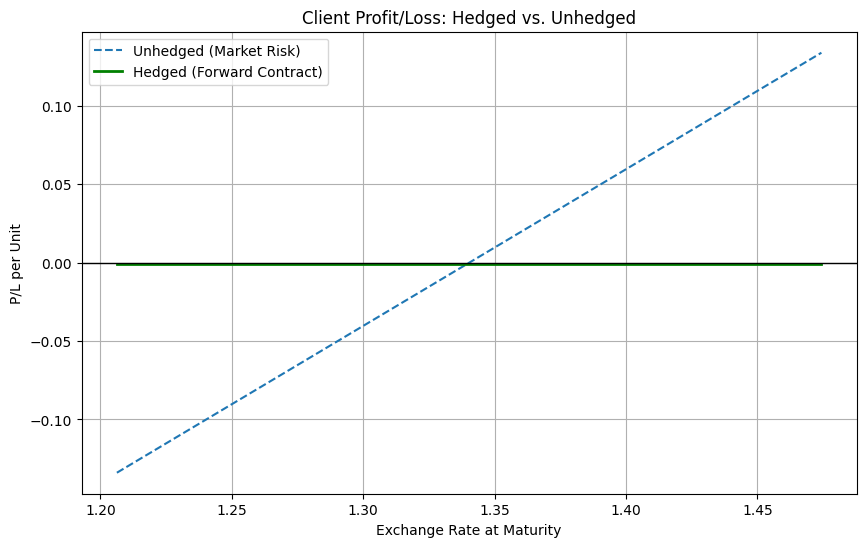

In [7]:
# Scenario Analysis
spots = np.linspace(spot * 0.9, spot * 1.1, 100)
forward_rate = spot * (1 + r_gbp * time) / (1 + r_usd * time)

unhedged_payoff = spots - spot
hedged_payoff = np.full_like(spots, forward_rate - spot)

plt.figure(figsize=(10, 6))
plt.plot(spots, unhedged_payoff, label='Unhedged (Market Risk)', linestyle='--')
plt.plot(spots, hedged_payoff, label='Hedged (Forward Contract)', color='green', linewidth=2)
plt.axhline(0, color='black', lw=1)
plt.title("Client Profit/Loss: Hedged vs. Unhedged")
plt.xlabel("Exchange Rate at Maturity")
plt.ylabel("P/L per Unit")
plt.legend()
plt.grid(True)
plt.show()

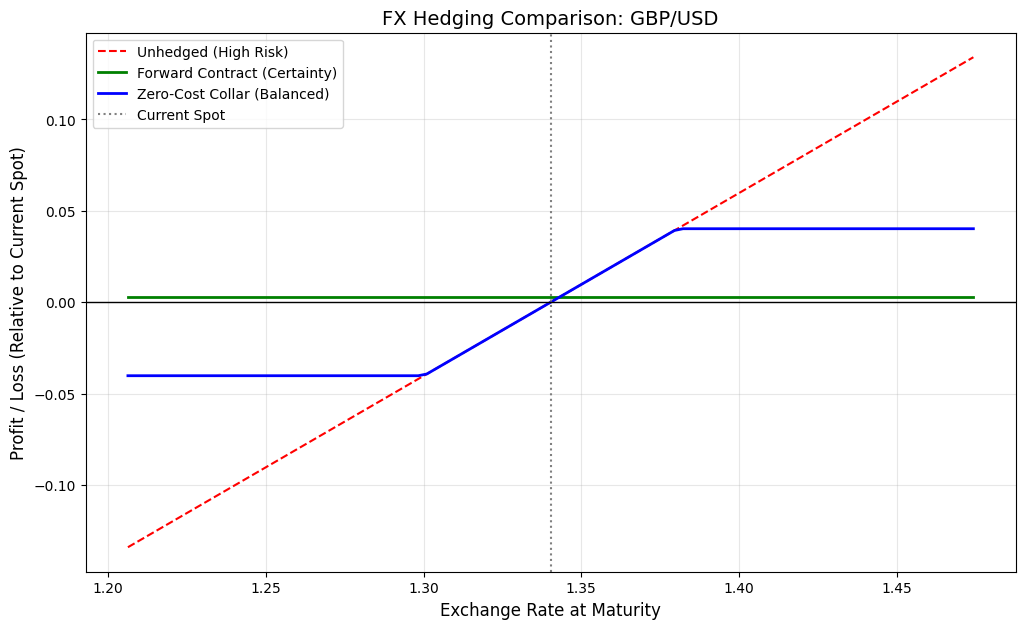

In [8]:
# 1. Define Range of possible Spot prices at maturity (+/- 10%)
spots = np.linspace(current_spot * 0.9, current_spot * 1.1, 100)

# 2. Define the Strategies
forward_rate = current_spot * 1.002 # Assuming a small interest rate carry
put_strike = current_spot * 0.97    # Protection 3% below market
call_strike = current_spot * 1.03   # Cap 3% above market

# 3. Calculate Payoffs
unhedged = spots - current_spot
forward = np.full_like(spots, forward_rate - current_spot)
# Collar Payoff: Floor at Put Strike, Cap at Call Strike
collar = np.clip(spots, put_strike, call_strike) - current_spot

# 4. Plotting
plt.figure(figsize=(12, 7))
plt.plot(spots, unhedged, label='Unhedged (High Risk)', color='red', linestyle='--')
plt.plot(spots, forward, label='Forward Contract (Certainty)', color='green', linewidth=2)
plt.plot(spots, collar, label='Zero-Cost Collar (Balanced)', color='blue', linewidth=2)

plt.axhline(0, color='black', lw=1)
plt.axvline(current_spot, color='grey', linestyle=':', label='Current Spot')

plt.title("FX Hedging Comparison: GBP/USD", fontsize=14)
plt.xlabel("Exchange Rate at Maturity", fontsize=12)
plt.ylabel("Profit / Loss (Relative to Current Spot)", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [9]:
print(f"Annualized Historical Volatility: {hist_vol:.2%}")

Annualized Historical Volatility: 7.12%
